In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.signal import find_peaks
from lib.readwav import *

In [ ]:
#leggo il file note_musicali.csv creando un dizionario con chiave il nome della nota e valore della frequenza
note_musicali = {}
with open('note_musicali.csv', 'r') as f:
    for line in f:
        note, freq = line.strip().split(',')
        note_musicali[note] = float(freq)


#leggo il file fundamental_frequencies.txt facendo un array con le frequenze fondamentali
fundamental_frequencies = np.loadtxt('fundamental_frequencies.txt')



In [16]:
np.max(fundamental_frequencies)

np.float64(1574.685179205683)

In [26]:
np.min(fundamental_frequencies)

np.float64(41.18600438554677)

In [27]:
# taglio il file note_musicali al massimo delle frequenze fondamentali e sotto al minimo delle frequenze fondamentali
note_musicali = {note: freq for note, freq in note_musicali.items() if freq <= np.max(fundamental_frequencies) and freq >= np.min(fundamental_frequencies)}

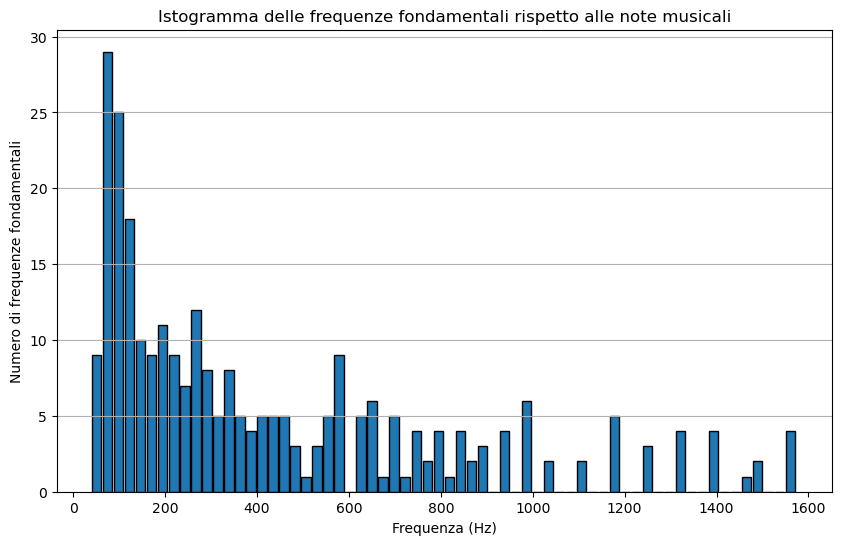

In [33]:
# guardo quante delle mie frequenze fondamentali sono presenti nel dizionario delle note musicali
#lo visualizzo con un istogramma
# i bin devono essere al centro delle frequenze delle note musicali ma larghi abbastanza da includere le frequenze fondamentali che sono vicine alle frequenze delle note musicali
# per ogni frequenza fondamentale, guardo se è presente nel dizionario delle note musicali
# se è presente, aggiungo 1 al bin corrispondente alla nota musicale

plt.figure(figsize=(10,6))
numero_bin = len(note_musicali)

larghezza_bin = 20 # Hz

plt.hist(fundamental_frequencies, bins=numero_bin, width=larghezza_bin, edgecolor='black')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Numero di frequenze fondamentali')
plt.title('Istogramma delle frequenze fondamentali rispetto alle note musicali')
# come tick metto il nome della nota musicale e la frequenza corrispondente
# e metto solo i tick dei bin che corrispondono alle frequenze delle note musicali


plt.grid(axis='y')
plt.show()